# 03. Classical Model and SHAP

Compare a one-feature lagged-volatility baseline with gradient boosting, then explain the
gradient boosting model with SHAP. The split is chronological and the test set is the most recent
25 percent of observations.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from src.classical_model import (
    compute_shap_values,
    evaluate_model,
    train_baseline_model,
    train_volatility_baseline,
)
from src.features import FEATURE_COLUMNS

## Load features and split chronologically

In [2]:
features = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)

X = features.drop(columns=['stress'])
y = features['stress']

# Chronological split: no shuffling, test set is the most recent 25%
split_idx = int(len(features) * 0.75)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} samples, {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Test:  {X_test.shape[0]} samples, {X_test.index.min().date()} to {X_test.index.max().date()}")
print(f"\nTrain stress rate: {y_train.mean():.3f}")
print(f"Test stress rate:  {y_test.mean():.3f}")

Train: 1401 samples, 2019-02-01 to 2024-08-26
Test:  467 samples, 2024-08-27 to 2026-07-10

Train stress rate: 0.206
Test stress rate:  0.060


## Train the one-feature and gradient boosting models

In [3]:
volatility_model = train_volatility_baseline(X_train, y_train)
model = train_baseline_model(X_train, y_train)
print("Models trained: lagged-volatility logistic baseline and GradientBoostingClassifier")

Models trained: lagged-volatility logistic baseline and GradientBoostingClassifier


## Evaluate on the held-out period

In [4]:
volatility_results = evaluate_model(
    volatility_model,
    X_test[["portfolio_vol"]],
    y_test,
)
gradient_results = evaluate_model(model, X_test, y_test)

results_df = pd.DataFrame([
    {"model": "lagged_volatility_logistic", **volatility_results},
    {"model": "gradient_boosting", **gradient_results},
])

results_df[[
    "model", "auc", "pr_auc", "brier", "precision", "recall",
    "tn", "fp", "fn", "tp",
]]

,model,auc,pr_auc,brier,precision,recall,tn,fp,fn,tp
0,lagged_volatility_logistic,0.997641,0.976077,0.018398,1.00,0.821429,439,0,5,23
1,gradient_boosting,0.994549,0.957384,0.011317,0.96,0.857143,438,1,4,24


In [5]:
results_df.to_csv('../data/processed/classical_results.csv', index=False)
print("Saved data/processed/classical_results.csv")

Saved data/processed/classical_results.csv


## SHAP explanation

Background dataset has 1401 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1401 when initializing the masker.


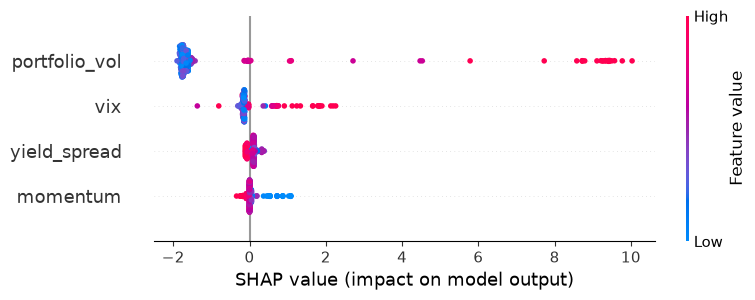

Saved figure: figures/03_shap_summary.png


In [6]:
shap_values = compute_shap_values(model, X_train, X_test)

fig = plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../figures/03_shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved figure: figures/03_shap_summary.png")

## Feature importance ranking

In [7]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=False)
print("Feature importance (mean |SHAP value|):")
print(importance)

Feature importance (mean |SHAP value|):
portfolio_vol    2.063143
vix              0.214035
yield_spread     0.105766
momentum         0.073647
dtype: float64


**Interpretation**: the lagged-volatility baseline has the stronger ranking metrics (AUC 0.998,
PR-AUC 0.976). Gradient boosting has a lower Brier score (0.011 versus 0.018) and slightly higher
recall at the fixed 0.5 threshold (0.857 versus 0.821). The extra variables therefore help
calibration and one additional stress-day detection, but not overall ranking. SHAP uses the
training period as its background; `portfolio_vol` remains the dominant feature.

## Feature order for the quantum model

The VQC receives the same four predefined features. SHAP is used for interpretation, not for
test-set-driven feature selection.

In [8]:
selected_features = FEATURE_COLUMNS
print(f"Model features: {selected_features}")
print(f"SHAP ranking: {list(importance.index)}")

Model features: ['portfolio_vol', 'vix', 'yield_spread', 'momentum']
SHAP ranking: ['portfolio_vol', 'vix', 'yield_spread', 'momentum']
